In [58]:
# === Cell 1: Load datasets ===

# === Cell: Restart Spark session with bigmem configuration ===

from pyspark.sql import SparkSession

# Stop any existing Spark session first
try:
    spark.stop()
    print("Stopped existing Spark session.")
except Exception as e:
    print("No active Spark session to stop:", e)

# Start new session with increased memory limits
spark = (
    SparkSession.builder
    .appName("community_notes_umap")
    .config("spark.driver.memory", "48g")
    .config("spark.executor.memory", "48g")
    .config("spark.sql.shuffle.partitions", "400")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark session reinitialized with bigmem configuration.")
print("Driver memory:", spark.sparkContext.getConf().get("spark.driver.memory"))
print("Executor memory:", spark.sparkContext.getConf().get("spark.executor.memory"))

# Base paths
basePath = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim"
ratingsPath = f"{basePath}/ratings_parquet/ratings_annotated.parquet"
topicsPath = f"{basePath}/processed/topics_by_note.parquet"
summaryPath = f"{basePath}/ratings_parquet/note_summary.parquet"

Stopped existing Spark session.
Spark session reinitialized with bigmem configuration.
Driver memory: 48g
Executor memory: 48g


Detected PCA dimensionality: 200


25/10/21 19:09:57 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


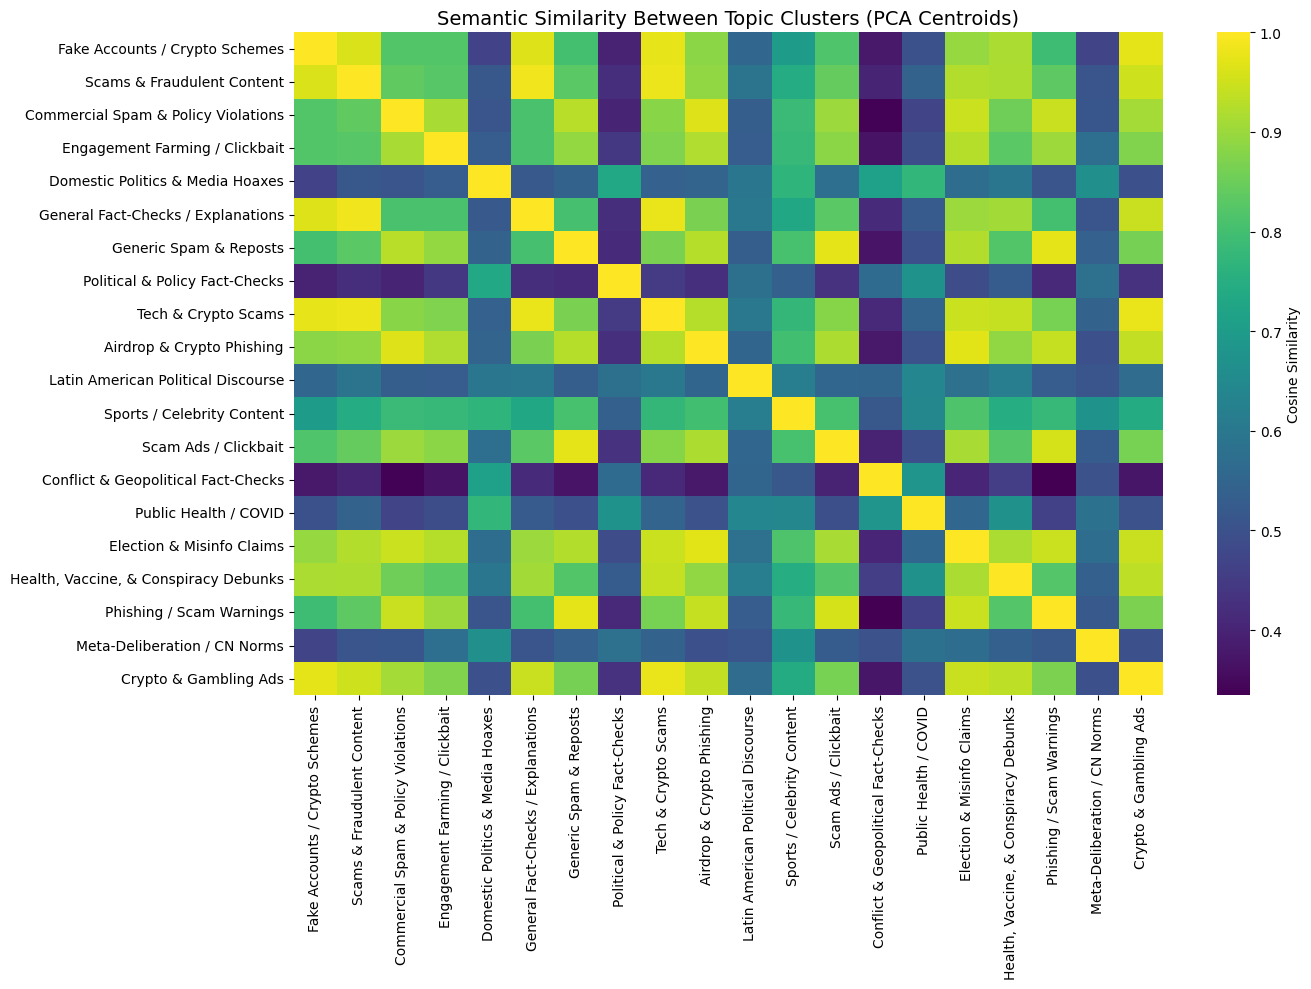

Saved cluster similarity matrix → /project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/cluster_similarity_matrix.csv


In [4]:
# ================================================================
#  COMPUTE CLUSTER CENTROIDS + HEATMAP (for Sparse PCA Vectors)
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array

# ----------------------------------------------------------------
# 1. Load PCA + topic labels
# ----------------------------------------------------------------
pca_path = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/embeddings/pca200_embeddings.parquet"
topics_path = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/notes_topics_labeled_with_labels.parquet"

dfPca = spark.read.parquet(pca_path).select("noteId", "pca200")
dfTopics = spark.read.parquet(topics_path).select("noteId", "topic_label")

# Join in Spark
dfJoined = dfPca.join(dfTopics, on="noteId", how="inner")

# ----------------------------------------------------------------
# 2. Convert MLlib vector to dense array
# ----------------------------------------------------------------
dfArray = dfJoined.withColumn("pcaArray", vector_to_array("pca200"))

# Detect PCA dimensionality automatically (e.g. 200)
dims = dfArray.select(F.size("pcaArray").alias("dim")).first()["dim"]
print(f"Detected PCA dimensionality: {dims}")

# ----------------------------------------------------------------
# 3. Compute centroids per topic (in Spark)
# ----------------------------------------------------------------
agg_exprs = [F.avg(F.col("pcaArray")[i]).alias(f"dim{i}") for i in range(dims)]
dfCentroids = dfArray.groupBy("topic_label").agg(*agg_exprs)

# ----------------------------------------------------------------
# 4. Bring only centroids into memory (~20 rows)
# ----------------------------------------------------------------
centroids_pdf = dfCentroids.toPandas()
topic_labels = centroids_pdf["topic_label"].tolist()
centroid_matrix = centroids_pdf[[f"dim{i}" for i in range(dims)]].to_numpy()

# ----------------------------------------------------------------
# 5. Compute cosine similarity + plot
# ----------------------------------------------------------------
similarity_matrix = cosine_similarity(centroid_matrix)

plt.figure(figsize=(14, 10))
sns.heatmap(
    similarity_matrix,
    xticklabels=topic_labels,
    yticklabels=topic_labels,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "Cosine Similarity"},
)
plt.title("Semantic Similarity Between Topic Clusters (PCA Centroids)", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# 6. Save similarity matrix
# ----------------------------------------------------------------
sim_df = pd.DataFrame(similarity_matrix, index=topic_labels, columns=topic_labels)
sim_out_csv = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/cluster_similarity_matrix.csv"
sim_df.to_csv(sim_out_csv)
print(f"Saved cluster similarity matrix → {sim_out_csv}")


sanity checks for the result

Symmetry error: 0.0
Diagonal mean: 1.0000000000000002
Value range: 0.334467558757013 1.0000000000000018
Off-diagonal mean: 0.6921199417257938


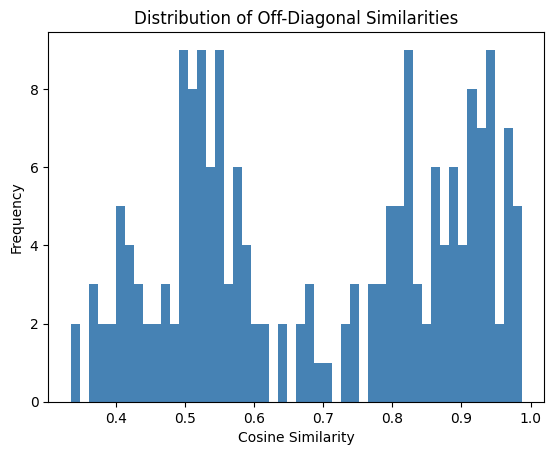

In [5]:
# --- Matrix Sanity Checks ---
import numpy as np

M = similarity_matrix
print("Symmetry error:", np.abs(M - M.T).max())
print("Diagonal mean:", np.mean(np.diag(M)))
print("Value range:", M.min(), M.max())
print("Off-diagonal mean:", (M.sum() - np.trace(M)) / (M.size - len(M)))

# Optional: visualize distribution
import matplotlib.pyplot as plt
plt.hist(M[np.triu_indices_from(M, k=1)].flatten(), bins=50, color='steelblue')
plt.title("Distribution of Off-Diagonal Similarities")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.show()


hierarchical dendrogram for meta topic construction

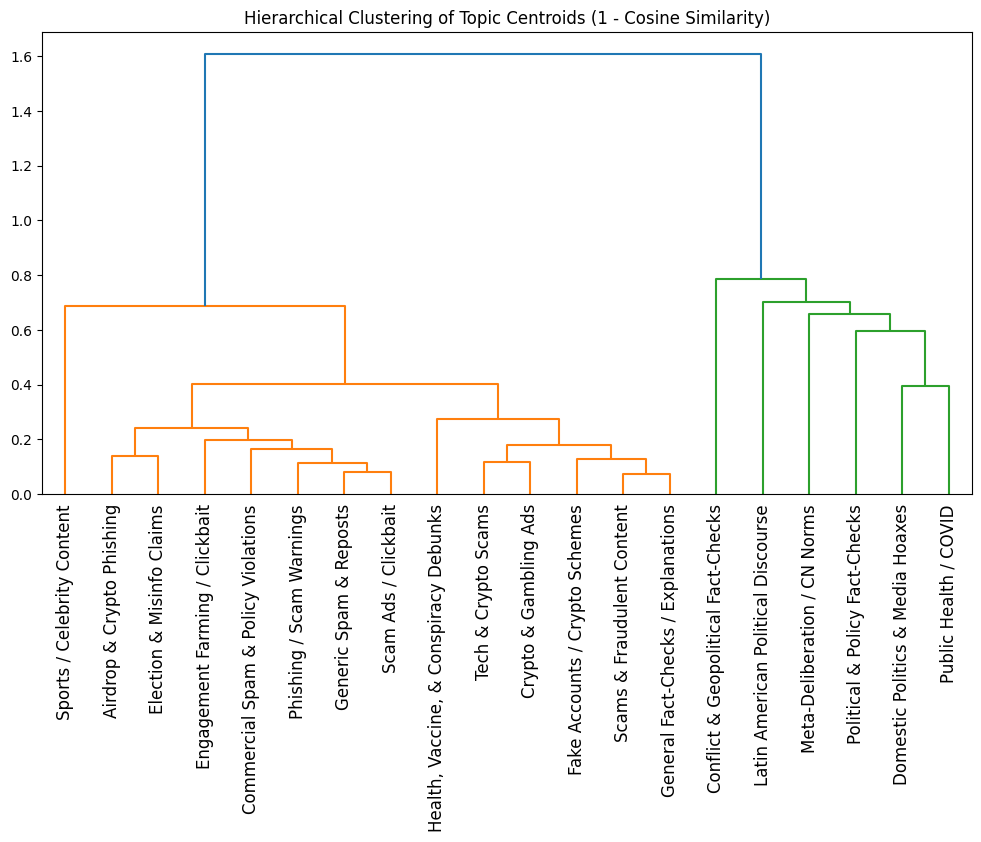

In [6]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(1 - similarity_matrix, method='average')
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=topic_labels, leaf_rotation=90)
plt.title("Hierarchical Clustering of Topic Centroids (1 - Cosine Similarity)")
plt.show()


I will now merge clusters that are extremely semantically similar, based on cosine similarity, to highlight distinguishable clusters in my data analysis.

In [ ]:
from collections import defaultdict

THRESHOLD = 0.87


In [8]:
# Build adjacency list based on threshold
adjacency = defaultdict(set)
for i, t1 in enumerate(sim_df.index):
    for j, t2 in enumerate(sim_df.columns):
        if i >= j:
            continue  # upper triangle only
        if sim_df.iloc[i, j] >= THRESHOLD:
            adjacency[t1].add(t2)
            adjacency[t2].add(t1)

# Find connected components (simple DFS)
visited = set()
merged_groups = []

for topic in sim_df.index:
    if topic not in visited:
        stack = [topic]
        group = []
        while stack:
            node = stack.pop()
            if node not in visited:
                visited.add(node)
                group.append(node)
                stack.extend(adjacency[node])
        merged_groups.append(group)

print(f"Detected {len(merged_groups)} merged topic groups at threshold {THRESHOLD}")
for g in merged_groups:
    print(" •", ", ".join(g))


Detected 8 merged topic groups at threshold 0.87
 • Fake Accounts / Crypto Schemes, Airdrop & Crypto Phishing, Health, Vaccine, & Conspiracy Debunks, Tech & Crypto Scams, Scams & Fraudulent Content, Crypto & Gambling Ads, Commercial Spam & Policy Violations, Generic Spam & Reposts, Phishing / Scam Warnings, Scam Ads / Clickbait, Election & Misinfo Claims, General Fact-Checks / Explanations, Engagement Farming / Clickbait
 • Domestic Politics & Media Hoaxes
 • Political & Policy Fact-Checks
 • Latin American Political Discourse
 • Sports / Celebrity Content
 • Conflict & Geopolitical Fact-Checks
 • Public Health / COVID
 • Meta-Deliberation / CN Norms


In [9]:
# Build mapping: each topic → merged_label
merged_mapping = {}
for idx, group in enumerate(merged_groups, 1):
    merged_name = " / ".join(sorted(group))
    for t in group:
        merged_mapping[t] = merged_name

# Convert to DataFrame for easy joins or saving
merged_df = pd.DataFrame(list(merged_mapping.items()), columns=["topic_label", "merged_label"])
display(merged_df.head())


,topic_label,merged_label
0,Fake Accounts / Crypto Schemes,Airdrop & Crypto Phishing / Commercial Spam & ...
1,Airdrop & Crypto Phishing,Airdrop & Crypto Phishing / Commercial Spam & ...
2,"Health, Vaccine, & Conspiracy Debunks",Airdrop & Crypto Phishing / Commercial Spam & ...
3,Tech & Crypto Scams,Airdrop & Crypto Phishing / Commercial Spam & ...
4,Scams & Fraudulent Content,Airdrop & Crypto Phishing / Commercial Spam & ...


In [10]:
out_dir = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs"
merged_df.to_csv(f"{out_dir}/topic_label_merges_{THRESHOLD}.csv", index=False)
print(f"Saved merged topic mapping → {out_dir}/topic_label_merges_{THRESHOLD}.csv")


Saved merged topic mapping → /project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/topic_label_merges_0.87.csv


In [11]:
# After building `merged_groups` from the previous step
print(f"\n=== Merged Topic Groups (threshold = {THRESHOLD}) ===")
print(f"Total groups formed: {len(merged_groups)}\n")

for i, group in enumerate(merged_groups, start=1):
    print(f"Group {i:02d}:")
    for topic in sorted(group):
        print(f"   • {topic}")
    print()



=== Merged Topic Groups (threshold = 0.87) ===
Total groups formed: 8

Group 01:
   • Airdrop & Crypto Phishing
   • Commercial Spam & Policy Violations
   • Crypto & Gambling Ads
   • Election & Misinfo Claims
   • Engagement Farming / Clickbait
   • Fake Accounts / Crypto Schemes
   • General Fact-Checks / Explanations
   • Generic Spam & Reposts
   • Health, Vaccine, & Conspiracy Debunks
   • Phishing / Scam Warnings
   • Scam Ads / Clickbait
   • Scams & Fraudulent Content
   • Tech & Crypto Scams

Group 02:
   • Domestic Politics & Media Hoaxes

Group 03:
   • Political & Policy Fact-Checks

Group 04:
   • Latin American Political Discourse

Group 05:
   • Sports / Celebrity Content

Group 06:
   • Conflict & Geopolitical Fact-Checks

Group 07:
   • Public Health / COVID

Group 08:
   • Meta-Deliberation / CN Norms



In [12]:
meta_mapping = {t: f"MetaGroup_{i+1}" for i, g in enumerate(merged_groups) for t in g}
meta_df = pd.DataFrame(list(meta_mapping.items()), columns=["topic_label", "meta_topic"])
meta_df.to_csv(f"{out_dir}/meta_topic_mapping_0.87.csv", index=False)


In [14]:
from pyspark.sql import functions as F

# Path to labeled topics parquet (the one that includes 'topic_label')
labeled_path = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/notes_topics_labeled_with_labels.parquet"

# Load the DataFrame
df_joined_labeled = spark.read.parquet(labeled_path)

# Quick sanity check
print("Loaded labeled topics:")
print(f"Rows: {df_joined_labeled.count():,}")
df_joined_labeled.show(5, truncate=False)


Loaded labeled topics:
Rows: 1,329,043
+-------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+--------------------------------+
|noteId             |summary                                                                                                                                                                                                                                                                                                                                                                           |topic|topic_label                     |
+-------------------+----------------------------------------------------------------------------